In [ ]:
# import numpy as np
# from pathlib import Path
# import json
# import neurokit2 as nk
# import warnings
# from tqdm.auto import tqdm

# signal_cache_dir  = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_npys")
# manifest_path     = signal_cache_dir / "manifest.jsonl"
# rows = [json.loads(line) for line in manifest_path.read_text().splitlines()]

# all_beat_lengths = []

# for row in tqdm(rows):
#     x = np.load(row["npy_path"], mmap_mode="r")
#     lead_ii = x[1]

#     try:
#         with warnings.catch_warnings():
#             warnings.simplefilter("ignore")
#             _, info = nk.ecg_peaks(lead_ii, sampling_rate=500)
#         r_peaks = np.array(info["ECG_R_Peaks"])
#     except Exception:
#         continue

#     if len(r_peaks) < 2:
#         continue

#     for i in range(len(r_peaks) - 1):
#         length = r_peaks[i + 1] - r_peaks[i]
#         if length >= 10:
#             all_beat_lengths.append(length)

# all_beat_lengths = np.array(all_beat_lengths)

# print(f"Total beats analyzed : {len(all_beat_lengths):,}")
# print(f"Min beat length      : {all_beat_lengths.min()} samples = {all_beat_lengths.min()/500*1000:.0f} ms")
# print(f"Max beat length      : {all_beat_lengths.max()} samples = {all_beat_lengths.max()/500*1000:.0f} ms")
# print(f"Mean beat length     : {all_beat_lengths.mean():.1f} samples = {all_beat_lengths.mean()/500*1000:.0f} ms")
# print(f"Median beat length   : {np.median(all_beat_lengths):.1f} samples = {np.median(all_beat_lengths)/500*1000:.0f} ms")
# print(f"Std beat length      : {all_beat_lengths.std():.1f} samples")
# print(f"95th percentile      : {np.percentile(all_beat_lengths, 95):.0f} samples = {np.percentile(all_beat_lengths, 95)/500*1000:.0f} ms")

  0%|          | 0/772591 [00:00<?, ?it/s]

Total beats analyzed : 8,942,175
Min beat length      : 151 samples = 302 ms
Max beat length      : 4803 samples = 9606 ms
Mean beat length     : 385.8 samples = 772 ms
Median beat length   : 375.0 samples = 750 ms
Std beat length      : 130.0 samples
95th percentile      : 566 samples = 1132 ms


In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import neurokit2 as nk
import warnings
from tqdm.auto import tqdm

# -------------------------
# Paths / config
# -------------------------
signal_cache_dir = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_npys")
raw_beat_cache_dir = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_beats_raw")
raw_beat_cache_dir.mkdir(parents=True, exist_ok=True)

manifest_path = signal_cache_dir / "manifest.jsonl"
rows = [json.loads(line) for line in manifest_path.read_text().splitlines()]
print(f"Loaded {len(rows):,} records from signal manifest")

SAMPLING_RATE = 500
MIN_BEATS     = 3

# -------------------------
# Functions
# -------------------------
def detect_r_peaks(lead_ii, sampling_rate=500):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _, info = nk.ecg_peaks(lead_ii, sampling_rate=sampling_rate)
        return np.array(info["ECG_R_Peaks"])
    except Exception:
        return np.array([])


def extract_raw_beats(x, sampling_rate=500):
    """
    x: (12, 5000) float32, already z-scored
    returns:
        beat_array: (N, 12, max_beat_len_in_record) zero-padded
        lengths:    (N,) actual length of each beat
    or None, None if detection fails
    """
    lead_ii = x[1]
    r_peaks = detect_r_peaks(lead_ii, sampling_rate=sampling_rate)

    if len(r_peaks) < 2:
        return None, None

    beats = []
    for i in range(len(r_peaks) - 1):
        start = r_peaks[i]
        end   = r_peaks[i + 1]
        beat  = x[:, start:end]   # (12, variable_length)
        if beat.shape[1] < 10:
            continue
        beats.append(beat)

    if len(beats) < MIN_BEATS:
        return None, None

    lengths       = np.array([b.shape[1] for b in beats], dtype=np.int32)
    max_beat_len  = lengths.max()

    beat_array = np.zeros((len(beats), 12, max_beat_len), dtype=np.float32)
    for i, beat in enumerate(beats):
        beat_array[i, :, :beat.shape[1]] = beat

    return beat_array, lengths


def raw_beat_cache_name(npy_path: str) -> str:
    h = hashlib.md5(npy_path.encode("utf-8")).hexdigest()
    return f"{h}.npz"

# -------------------------
# Precompute
# -------------------------
saved    = 0
skipped  = 0
raw_beat_manifest = []

for row in tqdm(rows):
    npy_path = row["npy_path"]
    out_name = raw_beat_cache_name(npy_path)
    out_path = raw_beat_cache_dir / out_name

    if out_path.exists():
        raw_beat_manifest.append({"npy_path": npy_path, "beat_path": str(out_path)})
        saved += 1
        continue

    x = np.load(npy_path, mmap_mode=None)

    if x.shape != (12, 5000):
        skipped += 1
        continue

    beat_array, lengths = extract_raw_beats(x, sampling_rate=SAMPLING_RATE)
    if beat_array is None:
        skipped += 1
        continue

    np.savez(out_path, beats=beat_array, lengths=lengths)
    raw_beat_manifest.append({"npy_path": npy_path, "beat_path": str(out_path)})
    saved += 1

raw_beat_manifest_path = raw_beat_cache_dir / "manifest.jsonl"
with raw_beat_manifest_path.open("w") as f:
    for row in raw_beat_manifest:
        f.write(json.dumps(row) + "\n")

print(f"Saved raw beat arrays : {saved:,}")
print(f"Skipped               : {skipped:,}")
print(f"Manifest              : {raw_beat_manifest_path}")

Loaded 772,591 records from signal manifest


  0%|          | 0/772591 [00:00<?, ?it/s]

Saved raw beat arrays : 766,267
Skipped               : 6,324
Manifest              : /data/ahmed/MIMIC_Dataset/mimic_precomputed_beats_raw/manifest.jsonl


In [1]:
from pathlib import Path
import random
import time
import math
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# -------------------------
# Reproducibility / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print("Device:", device)

# -------------------------
# Config
# -------------------------
MAX_BEATS    = 35
IN_CHANNELS  = 12
MAX_BEAT_LEN = 600                            # pred head output: 12 * 600 = 7200
MAX_TARGET_DIM = IN_CHANNELS * MAX_BEAT_LEN   # 7200

D_MODEL      = 256
NUM_HEADS    = 8
NUM_LAYERS   = 4
MLP_RATIO    = 4
DROPOUT      = 0.1

MASK_RATIO    = 0.50
MASK_SPAN_LEN = 1

MAX_RECORDS        = None
TRAIN_FRAC         = 0.95
BATCH_SIZE         = 256
NUM_WORKERS        = 12
PREFETCH_FACTOR    = 4
PIN_MEMORY         = True
PERSISTENT_WORKERS = True

EPOCHS       = 20
LR           = 2e-5
WEIGHT_DECAY = 0.05
LOG_EVERY    = 50
PLOT_EVERY   = 500

Device: cuda:1


In [2]:
class PrecomputedRawBeatDataset(Dataset):
    def __init__(self, beat_paths):
        self.beat_paths = beat_paths

    def __len__(self):
        return len(self.beat_paths)

    def __getitem__(self, idx):
        try:
            data    = np.load(self.beat_paths[idx])
            beats   = data["beats"]    # (N, 12, max_beat_len_in_record)
            lengths = data["lengths"]  # (N,)
            if beats.ndim != 3 or beats.shape[1] != 12:
                raise ValueError(f"Bad shape: {beats.shape}")
            return {
                "beats":      torch.from_numpy(beats),
                "lengths":    torch.from_numpy(lengths),
                "num_beats":  beats.shape[0],
            }
        except Exception:
            new_idx = random.randint(0, len(self) - 1)
            return self.__getitem__(new_idx)


def raw_beat_collate_fn(batch):
    num_beats  = [item["num_beats"] for item in batch]
    max_n      = max(num_beats)
    max_t = min(max(item["beats"].shape[2] for item in batch), MAX_BEAT_LEN)
    B          = len(batch)

    padded_beats  = torch.zeros(B, max_n, IN_CHANNELS, max_t)
    padding_mask  = torch.ones(B, max_n, dtype=torch.bool)
    beat_lengths  = torch.zeros(B, max_n, dtype=torch.long)

    for i, item in enumerate(batch):
        n = item["num_beats"]
        t = min(item["beats"].shape[2], MAX_BEAT_LEN)
        padded_beats[i, :n, :, :t] = item["beats"][:, :, :t]
        padding_mask[i, :n]        = False
        beat_lengths[i, :n]        = item["lengths"]

    return {
        "beats":        padded_beats,                  # (B, max_N, 12, max_T)
        "padding_mask": padding_mask,                  # (B, max_N)
        "beat_lengths": beat_lengths,                  # (B, max_N)
        "num_beats":    torch.tensor(num_beats),       # (B,)
    }

In [3]:
class AdaptivePoolingCNNTokenizer(nn.Module):
    def __init__(self, in_channels=12, d_model=256):
        super().__init__()
        self.proj = nn.Conv1d(
            in_channels=in_channels,
            out_channels=d_model,
            kernel_size=50,
            stride=50,
            bias=True,
        )
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # x: (B, 12, T) — T is variable
        z = self.proj(x)      # (B, d_model, T)
        z = self.pool(z)      # (B, d_model, 1)
        z = z.squeeze(-1)     # (B, d_model)
        return z.unsqueeze(1) # (B, 1, d_model)


class SinCosPositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        assert d_model % 2 == 0
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) *
            (-math.log(10000.0) / d_model)
        )
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(dtype=x.dtype, device=x.device)


class TransformerEncoder(nn.Module):
    def __init__(self, d_model=256, num_heads=8, num_layers=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * mlp_ratio,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

    def forward(self, x, src_key_padding_mask=None):
        return self.encoder(x, src_key_padding_mask=src_key_padding_mask)


def contiguous_token_mask(batch_size, seq_len, mask_ratio, device, span_len=1, max_tries=1000):
    num_mask = int(round(seq_len * mask_ratio))
    mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=device)

    for b in range(batch_size):
        tries = 0
        while int(mask[b].sum().item()) < num_mask and tries < max_tries:
            tries += 1
            remaining    = num_mask - int(mask[b].sum().item())
            current_span = min(span_len, remaining)
            start_max    = max(1, seq_len - current_span + 1)
            start        = torch.randint(0, start_max, (1,), device=device).item()
            end          = start + current_span
            if mask[b, start:end].any():
                continue
            mask[b, start:end] = True

        if int(mask[b].sum().item()) < num_mask:
            unmasked_idx = (~mask[b]).nonzero(as_tuple=False).squeeze(1)
            remaining    = num_mask - int(mask[b].sum().item())
            if len(unmasked_idx) > 0:
                pick = unmasked_idx[torch.randperm(len(unmasked_idx), device=device)[:remaining]]
                mask[b, pick] = True

    return mask


class ECGMaskedSSLBeatAdaptive(nn.Module):
    def __init__(self, in_channels=12, d_model=256,
                 num_heads=8, num_layers=4, mlp_ratio=4, dropout=0.1,
                 max_beats=35, max_target_dim=7200):
        super().__init__()
        self.max_target_dim = max_target_dim

        self.tokenizer  = AdaptivePoolingCNNTokenizer(in_channels, d_model)
        self.posenc     = SinCosPositionalEncoding(max_beats, d_model)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.encoder    = TransformerEncoder(d_model, num_heads, num_layers, mlp_ratio, dropout)

        self.pred_head  = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, max_target_dim),
        )

    def forward(self, beats, padding_mask=None, mask=None, mask_ratio=0.50, span_len=1):
        B, N, C, T = beats.shape
        target_dim = C * T   # 12 * max_T — varies per batch

        # tokenize each beat independently
        tokens = self.tokenizer(beats.view(B * N, C, T))  # (B*N, 1, D)
        tokens = tokens.squeeze(1).view(B, N, -1)         # (B, N, D)
        B, N, D = tokens.shape

        # reconstruction target — raw padded beat flattened
        target_patches = beats.reshape(B, N, target_dim)  # (B, N, 12*T)

        if mask is None:
            mask = contiguous_token_mask(B, N, mask_ratio, tokens.device, span_len=span_len)
        if padding_mask is not None:
            mask = mask & ~padding_mask

        mask_token    = self.mask_token.expand(B, N, D)
        masked_tokens = torch.where(mask.unsqueeze(-1), mask_token, tokens)
        masked_tokens = self.posenc(masked_tokens)

        encoded      = self.encoder(masked_tokens, src_key_padding_mask=padding_mask)
        pred_full    = self.pred_head(encoded)              # (B, N, max_target_dim)
        pred_patches = pred_full[:, :, :target_dim]        # (B, N, 12*T) truncate to match target

        if padding_mask is not None:
            real   = (~padding_mask).unsqueeze(-1).float()
            pooled = (encoded * real).sum(dim=1) / real.sum(dim=1).clamp(min=1)
        else:
            pooled = encoded.mean(dim=1)

        return {
            "pred_patches":   pred_patches,
            "target_patches": target_patches,
            "mask":           mask,
            "encoded":        encoded,
            "pooled":         pooled,
        }


def masked_patch_mse_loss(pred_patches, target_patches, mask, norm_target=False):
    pred_patches   = pred_patches.float()
    target_patches = target_patches.float()

    if norm_target:
        mean = target_patches.mean(dim=-1, keepdim=True)
        std  = target_patches.std(dim=-1,  keepdim=True).clamp(min=1e-6)
        target_patches = (target_patches - mean) / std
        pred_patches   = (pred_patches   - mean) / std

    mask_expanded = mask.unsqueeze(-1).expand_as(pred_patches)
    diff2 = (pred_patches - target_patches) ** 2
    return diff2[mask_expanded].mean()

In [4]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

CHECKPOINT_DIR = Path("./checkpoints_tok2_ssl")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

raw_beat_cache_dir    = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_beats_raw")
raw_beat_manifest_path = raw_beat_cache_dir / "manifest.jsonl"

rows       = [json.loads(line) for line in raw_beat_manifest_path.read_text().splitlines()]
beat_paths = [row["beat_path"] for row in rows]
print(f"Precomputed raw beat arrays loaded: {len(beat_paths):,}")

if MAX_RECORDS is not None:
    beat_paths = beat_paths[:MAX_RECORDS]

dataset = PrecomputedRawBeatDataset(beat_paths)

n_total = len(dataset)
n_train = int(TRAIN_FRAC * n_total)
n_val   = n_total - n_train

train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train size: {len(train_dataset):,}")
print(f"Val size  : {len(val_dataset):,}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
    collate_fn=raw_beat_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
    collate_fn=raw_beat_collate_fn,
)

Precomputed raw beat arrays loaded: 766,267
Train size: 727,953
Val size  : 38,314


In [5]:
model = ECGMaskedSSLBeatAdaptive(
    in_channels=IN_CHANNELS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    max_beats=MAX_BEATS,
    max_target_dim=MAX_TARGET_DIM,
).to(device)

model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

total_steps  = EPOCHS * len(train_loader)
warmup_steps = int(0.05 * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step + 1) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Total train steps : {total_steps:,}")
print(f"Warmup steps      : {warmup_steps:,}")

/tmp/ipykernel_3328462/1891472589.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Total train steps : 56,860
Warmup steps      : 2,843


In [6]:
def run_epoch(
    model,
    loader,
    optimizer=None,
    scheduler=None,
    train=True,
    global_step=0,
    plot_every=500,
    step_history=None,
    ema_alpha=0.03,
):
    model.train(train)

    running_loss = 0.0
    n_batches    = 0
    start_time   = time.time()

    grad_context = torch.enable_grad() if train else torch.no_grad()

    with grad_context:
        for step, batch in enumerate(loader, start=1):
            beats        = batch["beats"].to(device, non_blocking=True)
            padding_mask = batch["padding_mask"].to(device, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            mask = contiguous_token_mask(
                beats.shape[0], beats.shape[1], MASK_RATIO, device, span_len=MASK_SPAN_LEN
            )
            mask = mask & ~padding_mask

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                out = model(beats, padding_mask=padding_mask, mask=mask)

            loss = masked_patch_mse_loss(out["pred_patches"], out["target_patches"], out["mask"])

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

                global_step += 1
                batch_loss   = loss.item()

                if step_history is not None:
                    step_history["step"].append(global_step)
                    step_history["batch_loss"].append(batch_loss)
                    if len(step_history["ema_loss"]) == 0:
                        ema = batch_loss
                    else:
                        ema = ema_alpha * batch_loss + (1 - ema_alpha) * step_history["ema_loss"][-1]
                    step_history["ema_loss"].append(ema)

                if step_history is not None and global_step % plot_every == 0:
                    clear_output(wait=True)
                    plt.figure(figsize=(9, 5))
                    plt.plot(step_history["step"], step_history["batch_loss"], alpha=0.20, label="Batch loss")
                    plt.plot(step_history["step"], step_history["ema_loss"],   linewidth=2,  label="EMA loss")
                    plt.xlabel("Training step")
                    plt.ylabel("Loss")
                    plt.title("Tokenizer 2 SSL Training Monitor")
                    plt.grid(True, alpha=0.3)
                    plt.legend()
                    plt.show()

            running_loss += loss.item()
            n_batches    += 1

            if train and (step % LOG_EVERY == 0):
                elapsed    = time.time() - start_time
                avg_loss   = running_loss / n_batches
                current_lr = optimizer.param_groups[0]["lr"]
                print(
                    f"  step {step:5d}/{len(loader):5d} | "
                    f"batch_loss {loss.item():.4f} | "
                    f"avg_loss {avg_loss:.4f} | "
                    f"lr {current_lr:.2e} | "
                    f"{elapsed:.1f}s"
                )

    return running_loss / max(n_batches, 1), global_step

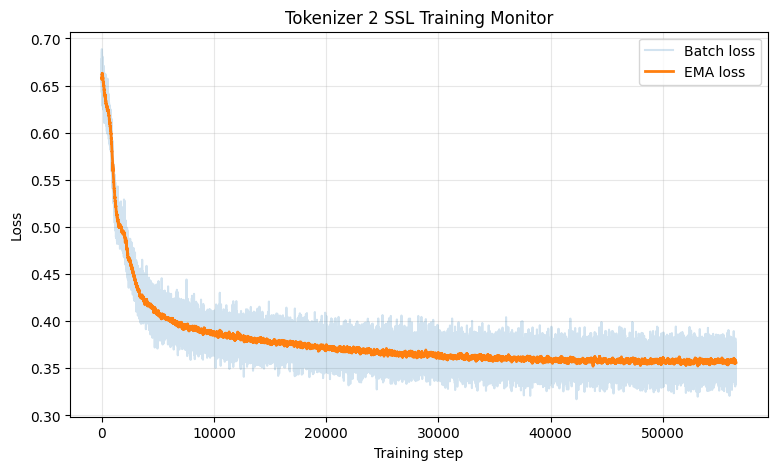

  step  2500/ 2843 | batch_loss 0.3356 | avg_loss 0.3573 | lr 1.99e-09 | 1283.5s
  step  2550/ 2843 | batch_loss 0.3605 | avg_loss 0.3572 | lr 1.45e-09 | 1309.3s
  step  2600/ 2843 | batch_loss 0.3482 | avg_loss 0.3572 | lr 9.99e-10 | 1335.1s
  step  2650/ 2843 | batch_loss 0.3652 | avg_loss 0.3572 | lr 6.30e-10 | 1360.6s
  step  2700/ 2843 | batch_loss 0.3460 | avg_loss 0.3572 | lr 3.46e-10 | 1385.6s
  step  2750/ 2843 | batch_loss 0.3487 | avg_loss 0.3573 | lr 1.46e-10 | 1411.5s
  step  2800/ 2843 | batch_loss 0.3624 | avg_loss 0.3572 | lr 3.13e-11 | 1437.0s
Epoch 20 | train_loss=0.3573 | val_loss=0.3538
  Saved new best checkpoint to: checkpoints_tok2_ssl/best.pt

Done training.
Best val loss: 0.35383830388387044
Checkpoint dir: checkpoints_tok2_ssl


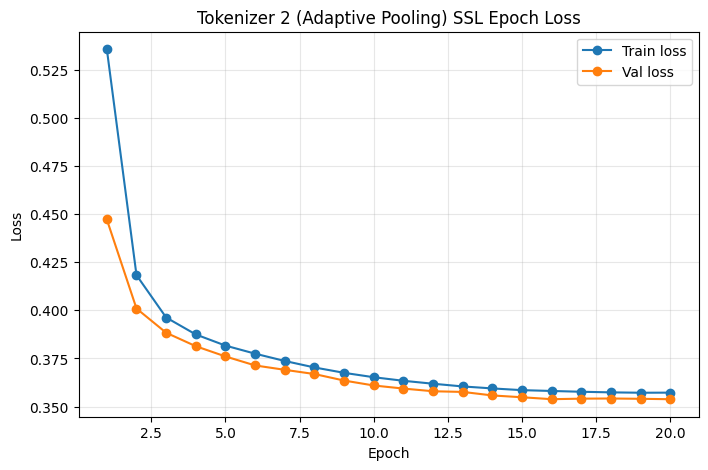

In [7]:
best_val_loss = float("inf")
history       = []
step_history  = {"step": [], "batch_loss": [], "ema_loss": []}
global_step   = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, global_step = run_epoch(
        model=model, loader=train_loader, optimizer=optimizer, scheduler=scheduler,
        train=True, global_step=global_step, plot_every=PLOT_EVERY, step_history=step_history,
    )

    val_loss, global_step = run_epoch(
        model=model, loader=val_loader, optimizer=None, scheduler=None,
        train=False, global_step=global_step, plot_every=PLOT_EVERY, step_history=None,
    )

    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    latest_path = CHECKPOINT_DIR / "latest.pt"
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "config": {
            "MAX_BEATS":       MAX_BEATS,
            "MAX_BEAT_LEN":    MAX_BEAT_LEN,
            "MAX_TARGET_DIM":  MAX_TARGET_DIM,
            "D_MODEL":         D_MODEL,
            "NUM_HEADS":       NUM_HEADS,
            "NUM_LAYERS":      NUM_LAYERS,
            "MASK_RATIO":      MASK_RATIO,
            "MASK_SPAN_LEN":   MASK_SPAN_LEN,
            "BATCH_SIZE":      BATCH_SIZE,
            "LR":              LR,
            "objective":       "beat_sync_adaptive_reconstruction",
        }
    }, latest_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = CHECKPOINT_DIR / "best.pt"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "config": {
                "MAX_BEATS":       MAX_BEATS,
                "MAX_BEAT_LEN":    MAX_BEAT_LEN,
                "MAX_TARGET_DIM":  MAX_TARGET_DIM,
                "D_MODEL":         D_MODEL,
                "NUM_HEADS":       NUM_HEADS,
                "NUM_LAYERS":      NUM_LAYERS,
                "MASK_RATIO":      MASK_RATIO,
                "MASK_SPAN_LEN":   MASK_SPAN_LEN,
                "BATCH_SIZE":      BATCH_SIZE,
                "LR":              LR,
                "objective":       "beat_sync_adaptive_reconstruction",
            }
        }, best_path)
        print(f"  Saved new best checkpoint to: {best_path}")

print("\nDone training.")
print("Best val loss:", best_val_loss)
print("Checkpoint dir:", CHECKPOINT_DIR)

epochs_list  = [x["epoch"]      for x in history]
train_losses = [x["train_loss"] for x in history]
val_losses   = [x["val_loss"]   for x in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs_list, train_losses, marker="o", label="Train loss")
plt.plot(epochs_list, val_losses,   marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tokenizer 2 (Adaptive Pooling) SSL Epoch Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/tmp/ipykernel_3328462/1891472589.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Loaded tokenizer 2 model from checkpoints_tok2_ssl/best.pt
Best val loss: 0.3538


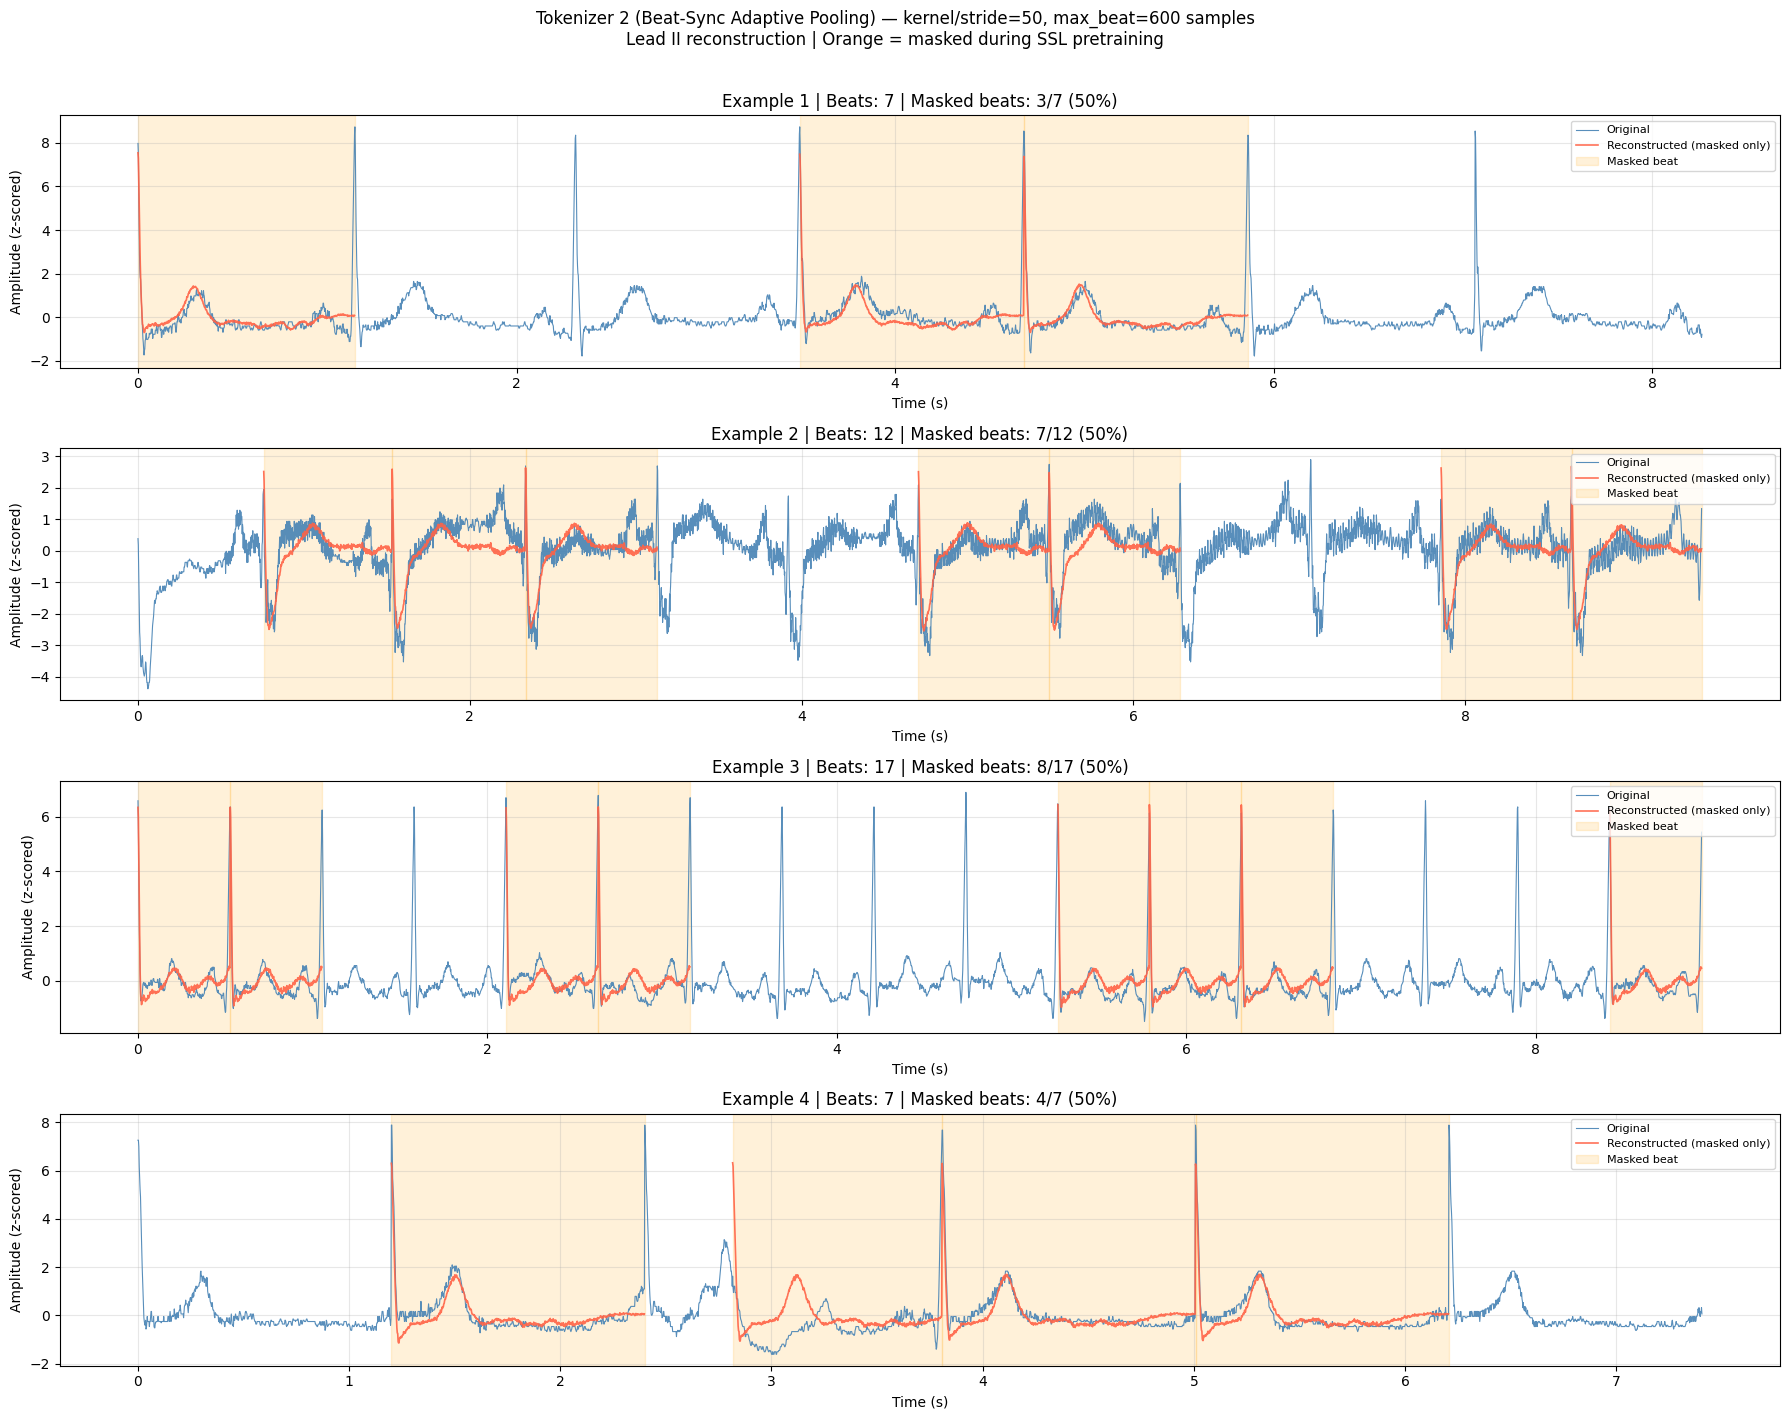

In [8]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import json
from pathlib import Path

# -------------------------
# Load tokenizer 2 model
# -------------------------
checkpoint_path = Path("checkpoints_tok2_ssl/best.pt")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

viz_model_adaptive = ECGMaskedSSLBeatAdaptive(
    in_channels=IN_CHANNELS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    max_beats=MAX_BEATS,
    max_target_dim=MAX_TARGET_DIM,
).to(device)

state_dict = checkpoint["model_state_dict"]
state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
viz_model_adaptive.load_state_dict(state_dict)
viz_model_adaptive.eval()
print(f"Loaded tokenizer 2 model from {checkpoint_path}")
print(f"Best val loss: {checkpoint['history'][-1]['val_loss']:.4f}")

# -------------------------
# Load 4 val samples from raw beat cache
# -------------------------
raw_beat_cache_dir    = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_beats_raw")
raw_beat_manifest_path = raw_beat_cache_dir / "manifest.jsonl"
rows = [json.loads(line) for line in raw_beat_manifest_path.read_text().splitlines()]

n_total  = len(rows)
n_train  = int(0.95 * n_total)
val_rows = rows[n_train:]
chosen   = np.random.choice(len(val_rows), size=4, replace=False)

samples        = []
lengths_list   = []
num_beats_list = []

for idx in chosen:
    data    = np.load(val_rows[idx]["beat_path"])
    beats   = data["beats"]    # (N, 12, max_beat_len_in_record)
    lengths = data["lengths"]  # (N,)
    samples.append(beats)
    lengths_list.append(lengths)
    num_beats_list.append(beats.shape[0])

# collate manually
max_n = max(num_beats_list)
max_t = min(max(s.shape[2] for s in samples), MAX_BEAT_LEN)
B     = len(samples)

padded_beats = np.zeros((B, max_n, 12, max_t), dtype=np.float32)
padding_mask = np.ones((B, max_n), dtype=bool)
beat_lengths = np.zeros((B, max_n), dtype=np.int32)

for i, (beats, lengths) in enumerate(zip(samples, lengths_list)):
    n = beats.shape[0]
    t = min(beats.shape[2], MAX_BEAT_LEN)
    padded_beats[i, :n, :, :t] = beats[:, :, :t]
    padding_mask[i, :n]        = False
    beat_lengths[i, :n]        = np.minimum(lengths, MAX_BEAT_LEN)

beats_tensor   = torch.from_numpy(padded_beats).to(device)
padding_tensor = torch.from_numpy(padding_mask).to(device)

# -------------------------
# Run model
# -------------------------
mask = contiguous_token_mask(B, max_n, MASK_RATIO, device, span_len=MASK_SPAN_LEN)
mask = mask & ~padding_tensor

with torch.no_grad():
    out = viz_model_adaptive(beats_tensor, padding_mask=padding_tensor, mask=mask)

pred    = out["pred_patches"].float().cpu().numpy()    # (4, max_N, target_dim)
target  = out["target_patches"].float().cpu().numpy()  # (4, max_N, target_dim)
mask_np = out["mask"].cpu().numpy()                    # (4, max_N)

# -------------------------
# Plot — one subplot per example
# Each beat plotted sequentially using actual beat lengths
# -------------------------
fig, axes = plt.subplots(4, 1, figsize=(18, 3.5 * 4))

for i in range(4):
    ax      = axes[i]
    n_real  = num_beats_list[i]
    T       = max_t   # padded beat length used in this batch

    original_signal       = []
    reconstructed_display = []
    actual_lengths        = beat_lengths[i, :n_real]

    for tok_idx in range(n_real):
        real_len = int(actual_lengths[tok_idx])

        # target and pred are flattened (12 * max_t,) — reshape and take lead II
        tgt_beat  = target[i, tok_idx].reshape(12, T)[1]   # Lead II
        pred_beat = pred[i, tok_idx].reshape(12, T)[1]     # Lead II

        # only use actual samples, not zero-padding
        original_signal.extend(tgt_beat[:real_len].tolist())

        if mask_np[i, tok_idx]:
            reconstructed_display.extend(pred_beat[:real_len].tolist())
        else:
            reconstructed_display.extend([np.nan] * real_len)

    original_signal       = np.array(original_signal)
    reconstructed_display = np.array(reconstructed_display)

    total_samples = len(original_signal)
    t = np.arange(total_samples) / 500.0   # seconds

    ax.plot(t, original_signal,       color='steelblue', linewidth=0.8, label='Original',                   alpha=0.9)
    ax.plot(t, reconstructed_display, color='tomato',    linewidth=1.2, label='Reconstructed (masked only)', alpha=0.9)

    # shade masked beats using actual lengths
    first_masked = True
    cumulative   = 0
    for tok_idx in range(n_real):
        real_len = int(actual_lengths[tok_idx])
        if mask_np[i, tok_idx]:
            start_t = cumulative / 500.0
            end_t   = (cumulative + real_len) / 500.0
            ax.axvspan(start_t, end_t, alpha=0.15, color='orange',
                       label='Masked beat' if first_masked else '')
            first_masked = False
        cumulative += real_len

    ax.set_title(f"Example {i+1} | Beats: {n_real} | "
                 f"Masked beats: {mask_np[i, :n_real].sum()}/{n_real} ({MASK_RATIO*100:.0f}%)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (z-scored)")
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Tokenizer 2 (Beat-Sync Adaptive Pooling) — kernel/stride=50, max_beat={MAX_BEAT_LEN} samples\n"
             f"Lead II reconstruction | Orange = masked during SSL pretraining",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()